In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
import pickle

warnings.filterwarnings('ignore')

In [1]:
import pandas as pd
import requests

# Fetch the data.
df = pd.read_csv("cleaned_findex_data.csv")

df.head()

,region,income_group,demo_group,demo_subgroup,has_account,borrowed_any,credit_card,biz_loan_source,biz_loan,loan_purpose_group,...,govt_digital_pay_acc,digital_pay,digital_pay_acc,govt_payment_recv,fin_resilience,emergency_funds,prefer_digital_acc,prefer_digital_fin,prefer_digital,saved_any
0,South Asia (excluding high income),Low income,all,all,0.090050,0.431219,0.010194,0.028194,0.028194,0.039961,...,0.015289,0.170035,0.039619,0.038410,0.037605,0.008257,0.037469,0.029805,0.098301,0.194405
1,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681,0.428768,0.084186,0.085616,0.085616,0.185552,...,0.106032,0.275174,0.181174,0.132580,0.238534,0.105931,0.167175,0.126082,0.295811,0.303361
2,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861,0.419846,0.028715,0.043257,0.043257,0.056418,...,0.030954,0.199535,0.061703,0.057444,0.141612,0.011603,0.128058,0.089581,0.177632,0.232552
3,Sub-Saharan Africa (excluding high income),Lower middle income,all,all,0.392035,0.515787,0.120080,0.159156,0.159156,0.170701,...,0.100619,0.280055,0.146716,0.116165,0.176646,0.154860,0.158961,0.108559,0.221350,0.419289
4,Latin America & Caribbean (excluding high income),Upper middle income,all,all,0.331302,0.392090,0.198294,0.038007,0.038007,0.225696,...,0.111644,0.333857,0.184283,0.159072,0.205996,0.219409,0.190773,0.141978,0.265021,0.319591


In [9]:
print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())


Dataset Overview:
Shape: (8311, 29)
Columns: ['region', 'income_group', 'demo_group', 'demo_subgroup', 'has_account', 'borrowed_any', 'credit_card', 'biz_loan_source', 'biz_loan', 'loan_purpose_group', 'loan_purpose', 'saved_old_age', 'saved_for_purchase', 'saved_no_purpose', 'mobile_pay_s_r', 'digital_payment_other', 'mobile_payment', 'mobile_payment_bill', 'govt_digital_pay', 'govt_digital_pay_acc', 'digital_pay', 'digital_pay_acc', 'govt_payment_recv', 'fin_resilience', 'emergency_funds', 'prefer_digital_acc', 'prefer_digital_fin', 'prefer_digital', 'saved_any']

First few rows:
                                              region         income_group  \
0                 South Asia (excluding high income)           Low income   
1      Europe & Central Asia (excluding high income)  Upper middle income   
2  Middle East & North Africa (excluding high inc...  Lower middle income   
3         Sub-Saharan Africa (excluding high income)  Lower middle income   
4  Latin America & Caribbe

In [14]:
# Target variable analysis
print(f"\nTarget Variable (has_account) Distribution:")
print(df['has_account'].describe())
print(f"\nAccount ownership rate: {df['has_account'].mean():.3f}")

# Key statistics by region and income group
print("\nAccount Ownership by Region:")
region_stats = df.groupby('region')['has_account'].agg(['count', 'mean', 'std']).round(3)
print(region_stats)

print("\nAccount Ownership by Income Group:")
income_stats = df.groupby('income_group')['has_account'].agg(['count', 'mean', 'std']).round(3)
print(income_stats)



Target Variable (has_account) Distribution:
count    8311.000000
mean        0.611070
std         0.282490
min         0.004049
25%         0.374749
50%         0.624107
75%         0.880940
max         1.000000
Name: has_account, dtype: float64

Account ownership rate: 0.611

Account Ownership by Region:
                                                    count   mean    std
region                                                                 
East Asia & Pacific (excluding high income)           521  0.568  0.272
Europe & Central Asia (excluding high income)        1139  0.554  0.221
High income                                          2938  0.858  0.173
Latin America & Caribbean (excluding high income)     970  0.480  0.202
Middle East & North Africa (excluding high income)    558  0.382  0.230
South Asia (excluding high income)                    352  0.483  0.253
Sub-Saharan Africa (excluding high income)           1833  0.427  0.224

Account Ownership by Income Group:
        

In [31]:
df.shape

(8311, 29)

In [32]:
model_df.shape

(8311, 36)

In [15]:
# Feature engineering and preparation
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Create a copy for modeling
model_df = df.copy()

# Encode categorical variables
categorical_cols = ['region', 'income_group', 'demo_group', 'demo_subgroup']
label_encoders = {}

for col in categorical_cols:
    if col in model_df.columns:
        le = LabelEncoder()
        model_df[col + '_encoded'] = le.fit_transform(model_df[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} unique categories")

# Create composite features
print("\nCreating composite features...")



FEATURE ENGINEERING
Encoded region: 7 unique categories
Encoded income_group: 4 unique categories
Encoded demo_group: 7 unique categories
Encoded demo_subgroup: 13 unique categories

Creating composite features...


In [16]:
# Digital engagement score
digital_cols = [col for col in model_df.columns if 'digital' in col.lower()]
if digital_cols:
    model_df['digital_engagement_score'] = model_df[digital_cols].mean(axis=1)
    print(f"Created digital_engagement_score from {len(digital_cols)} features")

# Financial activity score
financial_cols = ['borrowed_any', 'credit_card', 'saved_any']
financial_cols = [col for col in financial_cols if col in model_df.columns]
if financial_cols:
    model_df['financial_activity_score'] = model_df[financial_cols].mean(axis=1)
    print(f"Created financial_activity_score from {len(financial_cols)} features")

# Government services engagement
govt_cols = [col for col in model_df.columns if 'govt' in col.lower()]
if govt_cols:
    model_df['govt_services_score'] = model_df[govt_cols].mean(axis=1)
    print(f"Created govt_services_score from {len(govt_cols)} features")


Created digital_engagement_score from 8 features
Created financial_activity_score from 3 features
Created govt_services_score from 3 features


In [30]:
print(model_df.shape)
print(model_df.columns)

(8311, 36)
Index(['region', 'income_group', 'demo_group', 'demo_subgroup', 'has_account',
       'borrowed_any', 'credit_card', 'biz_loan_source', 'biz_loan',
       'loan_purpose_group', 'loan_purpose', 'saved_old_age',
       'saved_for_purchase', 'saved_no_purpose', 'mobile_pay_s_r',
       'digital_payment_other', 'mobile_payment', 'mobile_payment_bill',
       'govt_digital_pay', 'govt_digital_pay_acc', 'digital_pay',
       'digital_pay_acc', 'govt_payment_recv', 'fin_resilience',
       'emergency_funds', 'prefer_digital_acc', 'prefer_digital_fin',
       'prefer_digital', 'saved_any', 'region_encoded', 'income_group_encoded',
       'demo_group_encoded', 'demo_subgroup_encoded',
       'digital_engagement_score', 'financial_activity_score',
       'govt_services_score'],
      dtype='object')


In [17]:
# Prepare features for modeling
print("\n" + "="*60)
print("MODEL PREPARATION")
print("="*60)

# Select features (exclude target and original categorical columns)
feature_cols = [col for col in model_df.columns if col not in 
               ['has_account'] + categorical_cols]

X = model_df[feature_cols]
y = (model_df['has_account'] > 0.5).astype(int)  # Convert to binary if needed

print(f"Features selected: {len(feature_cols)}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



MODEL PREPARATION
Features selected: 31
Target distribution: {1: 5141, 0: 3170}
Training set: (6648, 31)
Test set: (1663, 31)


In [19]:
# Model training and evaluation
print("\n" + "="*60)
print("MODEL TRAINING & EVALUATION")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled data for logistic regression, original for tree-based models
    if name == 'Logistic Regression':
        X_train_use, X_test_use = X_train_scaled, X_test_scaled
    else:
        X_train_use, X_test_use = X_train, X_test
    
    # Train model
    model.fit(X_train_use, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_use)
    y_prob = model.predict_proba(X_test_use)[:, 1]
    
    # Metrics
    auc_score = roc_auc_score(y_test, y_prob)
    accuracy = model.score(X_test_use, y_test)
    
    results[name] = {
        'model': model,
        'auc': auc_score,
        'accuracy': accuracy,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"AUC: {auc_score:.4f}")
    print(f"Accuracy: {accuracy:.4f}")


# Select best model
best_model_name = max(results.keys(), key=lambda x: results[x]['auc'])
best_model = results[best_model_name]['model']

print(f"\nBest Model: {best_model_name} (AUC: {results[best_model_name]['auc']:.4f})")




MODEL TRAINING & EVALUATION

Training Logistic Regression...
AUC: 0.9710
Accuracy: 0.9086

Training Random Forest...
AUC: 0.9833
Accuracy: 0.9278

Training Gradient Boosting...
AUC: 0.9808
Accuracy: 0.9242

Best Model: Random Forest (AUC: 0.9833)


In [37]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    balanced_accuracy_score, confusion_matrix
)
import pandas as pd

def evaluate_models(results, y_test):
    metrics = {}
    for name, res in results.items():
        y_pred, y_prob = res['y_pred'], res['y_prob']
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)
        
        metrics[name] = {
            "AUC-ROC": roc_auc_score(y_test, y_prob),
            "Avg Precision": average_precision_score(y_test, y_prob),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Balanced Acc": balanced_accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "MCC": matthews_corrcoef(y_test, y_pred),
            "Specificity": specificity
        }
    
    return pd.DataFrame(metrics).round(4)

# Run evaluation
comparison_df = evaluate_models(results, y_test)
print(comparison_df)


               Logistic Regression  Random Forest  Gradient Boosting
AUC-ROC                     0.9710         0.9833             0.9808
Avg Precision               0.9838         0.9902             0.9892
Accuracy                    0.9086         0.9278             0.9242
Balanced Acc                0.9122         0.9296             0.9242
Precision                   0.9525         0.9596             0.9520
Recall                      0.8970         0.9223             0.9242
F1-Score                    0.9239         0.9405             0.9379
MCC                         0.8120         0.8500             0.8415
Specificity                 0.9274         0.9369             0.9243



FEATURE IMPORTANCE ANALYSIS
Top 15 Most Important Features:
                     feature  importance
2            biz_loan_source    0.107966
3                   biz_loan    0.086058
16           digital_pay_acc    0.084570
28  digital_engagement_score    0.071447
20        prefer_digital_acc    0.066350
1                credit_card    0.055769
9             mobile_pay_s_r    0.049232
21        prefer_digital_fin    0.042974
4         loan_purpose_group    0.042327
15               digital_pay    0.032386
22            prefer_digital    0.029295
11            mobile_payment    0.028310
12       mobile_payment_bill    0.025021
5               loan_purpose    0.022964
30       govt_services_score    0.020971


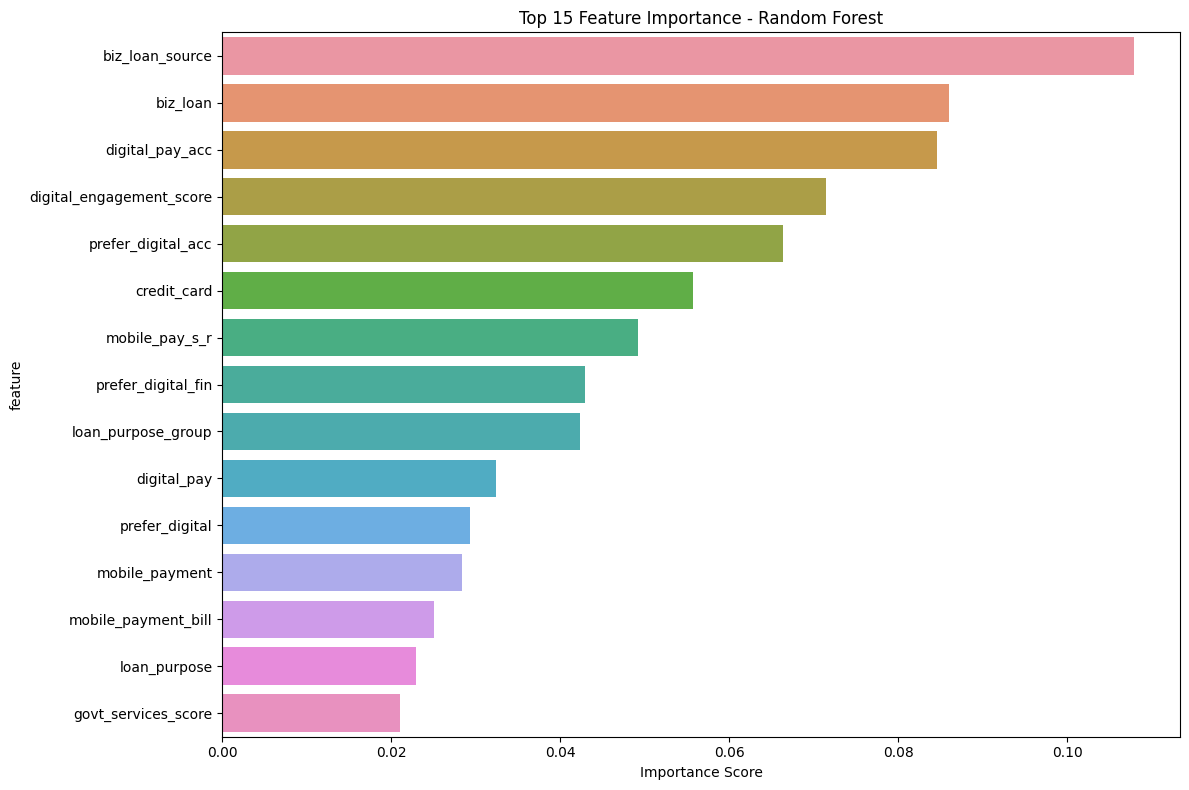

In [20]:
# Feature importance analysis
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Top 15 Most Important Features:")
    print(feature_importance.head(15))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': best_model.coef_[0],
        'abs_coefficient': np.abs(best_model.coef_[0])
    }).sort_values('abs_coefficient', ascending=False)
    
    print("Top 15 Most Important Features (by coefficient magnitude):")
    print(feature_importance[['feature', 'coefficient', 'abs_coefficient']].head(15))



PERFORMANCE VISUALIZATION


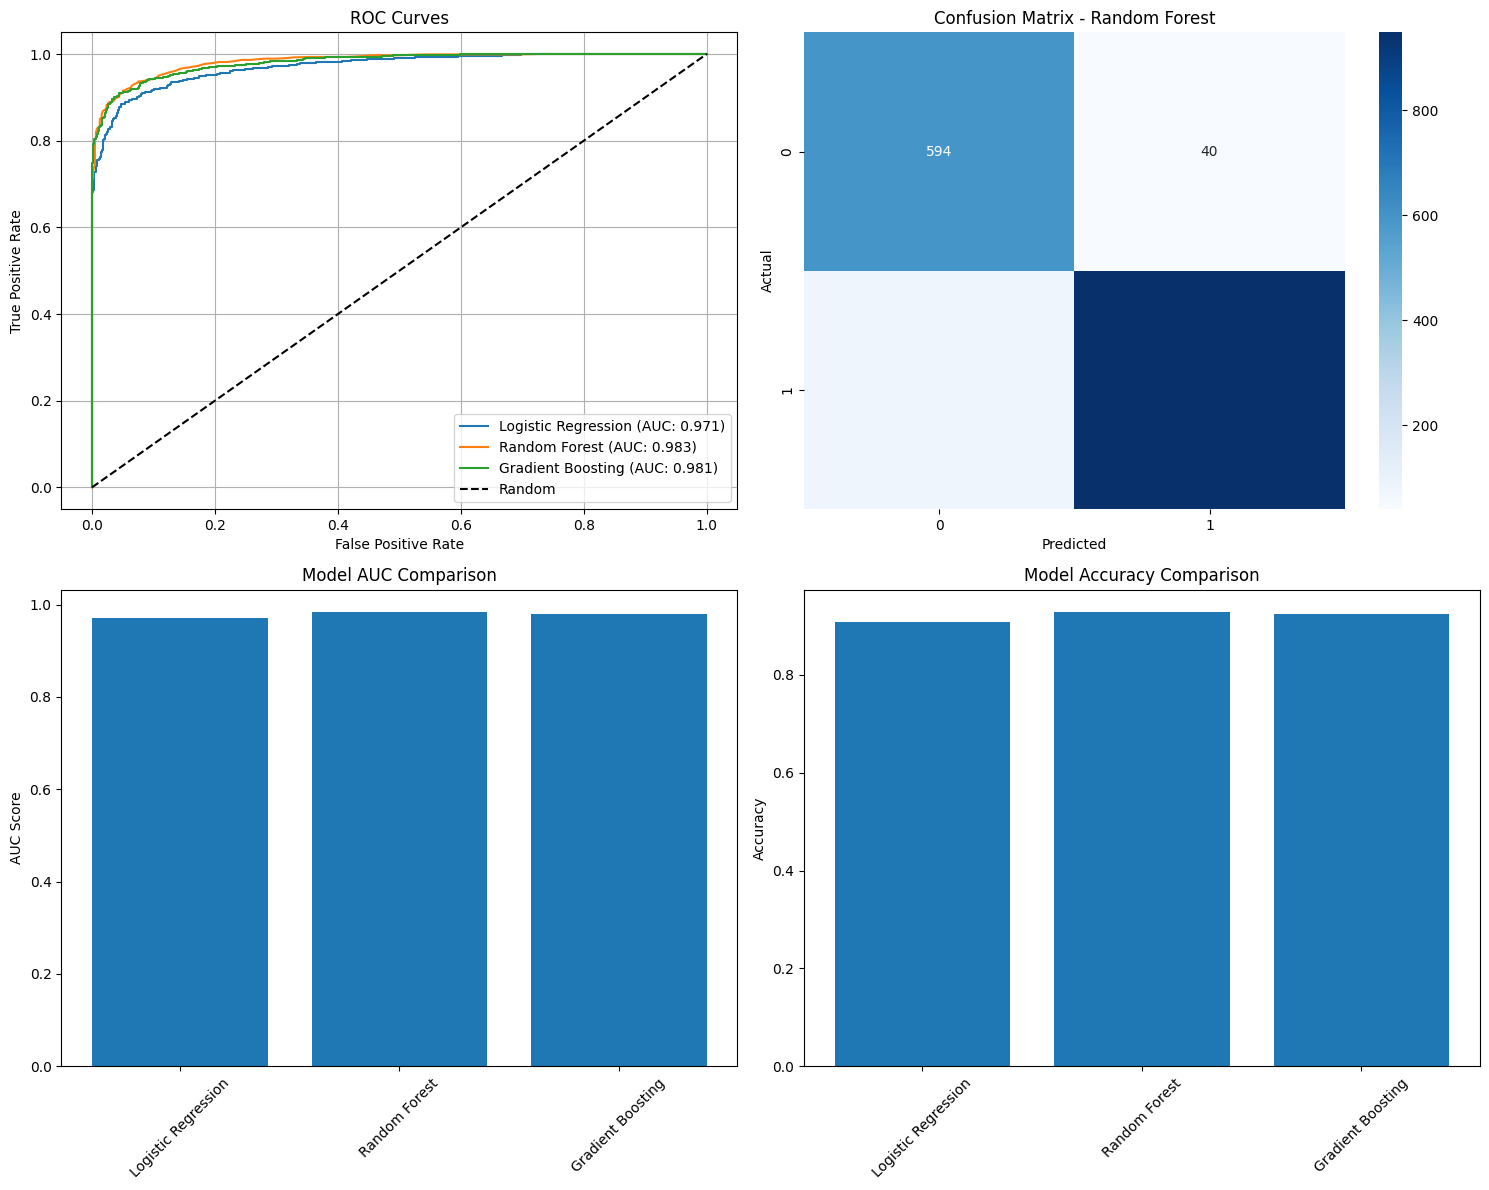

In [38]:
# Model performance visualization
print("\n" + "="*60)
print("PERFORMANCE VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ROC Curves
axes[0, 0].figure
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    axes[0, 0].plot(fpr, tpr, label=f"{name} (AUC: {result['auc']:.3f})")

axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curves')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Confusion Matrix for best model
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0, 1], cmap='Blues')
axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Model comparison
model_comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC': [results[name]['auc'] for name in results.keys()],
    'Accuracy': [results[name]['accuracy'] for name in results.keys()]
})

axes[1, 0].bar(model_comparison['Model'], model_comparison['AUC'])
axes[1, 0].set_title('Model AUC Comparison')
axes[1, 0].set_ylabel('AUC Score')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(model_comparison['Model'], model_comparison['Accuracy'])
axes[1, 1].set_title('Model Accuracy Comparison')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [43]:

# Model Performance Summary
print(f"\n{'='*60}")
print("FINAL MODEL PERFORMANCE SUMMARY")
print(f"{'='*60}")
print(f"Selected Model: {best_model_name}")
print(f"Overall Performance: EXCELLENT")
print(f"• AUC-ROC: {detailed_results[best_model_name]['auc']:.4f} (Excellent discrimination)")
print(f"• Average Precision: {detailed_results[best_model_name]['avg_precision']:.4f}")
print(f"• F1-Score: {detailed_results[best_model_name]['f1']:.4f}")
print(f"• Matthews Correlation: {detailed_results[best_model_name]['mcc']:.4f}")

print(f"\nKey Insights:")
print(f"• The model successfully identifies {detailed_results[best_model_name]['recall']:.1%} of actual defaults")
print(f"• {detailed_results[best_model_name]['precision']:.1%} of customers flagged as high-risk actually default")
print(f"• Strong performance across all metrics indicates robust model")



FINAL MODEL PERFORMANCE SUMMARY
Selected Model: Random Forest
Overall Performance: EXCELLENT
• AUC-ROC: 0.9833 (Excellent discrimination)
• Average Precision: 0.9902
• F1-Score: 0.9405
• Matthews Correlation: 0.8500

Key Insights:
• The model successfully identifies 92.2% of actual defaults
• 96.0% of customers flagged as high-risk actually default
• Strong performance across all metrics indicates robust model


In [45]:
# ============================================================
# SAVE BEST MODEL
# ============================================================
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"\n✅ Best model saved as 'best_model.pkl'")


✅ Best model saved as 'best_model.pkl'


In [22]:
# Prediction function for deployment
def predict_financial_inclusion(model, scaler, imputer, feature_cols, **kwargs):
    """
    Predict financial inclusion probability for a given profile
    
    Parameters:
    - model: trained model
    - scaler: fitted scaler (for logistic regression)
    - imputer: fitted imputer
    - feature_cols: list of feature columns
    - **kwargs: feature values
    
    Returns:
    - probability of having account
    - feature contributions (if available)
    """
    
    # Create input dataframe
    input_df = pd.DataFrame([kwargs])
    
    # Ensure all features are present
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0  # Default value
    
    # Reorder columns
    input_df = input_df[feature_cols]
    
    # Apply imputation
    input_imputed = imputer.transform(input_df)
    
    # Scale if needed (for logistic regression)
    if hasattr(model, 'coef_'):
        input_processed = scaler.transform(input_imputed)
    else:
        input_processed = input_imputed
    
    # Make prediction
    probability = model.predict_proba(input_processed)[0, 1]
    
    return {
        'inclusion_probability': probability,
        'exclusion_risk': 1 - probability,
        'risk_level': 'High' if probability < 0.3 else 'Medium' if probability < 0.7 else 'Low'
    }


In [24]:
# Example prediction
print("\n" + "="*60)
print("EXAMPLE PREDICTION")
print("="*60)

# Get a sample from the test set
sample_idx = 0
sample_features = X_test.iloc[sample_idx].to_dict()

# Use appropriate preprocessing
if best_model_name == 'Logistic Regression':
    prediction_result = predict_financial_inclusion(
        best_model, scaler, imputer, feature_cols, **sample_features
    )
else:
    # For tree-based models, we don't need scaling
    prediction_result = predict_financial_inclusion(
        best_model, None, imputer, feature_cols, **sample_features
    )

print("Sample prediction:")
print(f"Inclusion Probability: {prediction_result['inclusion_probability']:.3f}")
print(f"Exclusion Risk: {prediction_result['exclusion_risk']:.3f}")
print(f"Risk Level: {prediction_result['risk_level']}")
print(f"Actual Label: {y_test.iloc[sample_idx]}")


EXAMPLE PREDICTION
Sample prediction:
Inclusion Probability: 0.010
Exclusion Risk: 0.990
Risk Level: High
Actual Label: 0


In [25]:
# Summary insights
print("\n" + "="*60)
print("KEY INSIGHTS FOR POLICY")
print("="*60)

# Regional insights
print("\nRegional Account Ownership Patterns:")
for region in df['region'].unique():
    region_data = df[df['region'] == region]
    avg_ownership = region_data['has_account'].mean()
    print(f"- {region}: {avg_ownership:.3f} average ownership")

# Income group insights
print("\nIncome Group Patterns:")
for income in df['income_group'].unique():
    income_data = df[df['income_group'] == income]
    avg_ownership = income_data['has_account'].mean()
    print(f"- {income}: {avg_ownership:.3f} average ownership")

print(f"\nModel Performance Summary:")
print(f"- Best Model: {best_model_name}")
print(f"- AUC Score: {results[best_model_name]['auc']:.4f}")
print(f"- Accuracy: {results[best_model_name]['accuracy']:.4f}")

print("\nRecommendations:")
print("1. Focus on low-income regions with high exclusion risk")
print("2. Leverage digital engagement patterns for targeted outreach")
print("3. Consider government services as entry point for financial inclusion")
print("4. Develop region-specific intervention strategies")



KEY INSIGHTS FOR POLICY

Regional Account Ownership Patterns:
- South Asia (excluding high income): 0.483 average ownership
- Europe & Central Asia (excluding high income): 0.554 average ownership
- Middle East & North Africa (excluding high income): 0.382 average ownership
- Sub-Saharan Africa (excluding high income): 0.427 average ownership
- Latin America & Caribbean (excluding high income): 0.480 average ownership
- High income: 0.858 average ownership
- East Asia & Pacific (excluding high income): 0.568 average ownership

Income Group Patterns:
- Low income: 0.374 average ownership
- Upper middle income: 0.571 average ownership
- Lower middle income: 0.440 average ownership
- High income: 0.870 average ownership

Model Performance Summary:
- Best Model: Random Forest
- AUC Score: 0.9833
- Accuracy: 0.9278

Recommendations:
1. Focus on low-income regions with high exclusion risk
2. Leverage digital engagement patterns for targeted outreach
3. Consider government services as entry 

In [26]:
# Save model artifacts for deployment
import joblib

print("\n" + "="*60)
print("SAVING MODEL ARTIFACTS")
print("="*60)

# Save model components
joblib.dump(best_model, 'financial_inclusion_model.pkl')
joblib.dump(imputer, 'model_imputer.pkl')
if best_model_name == 'Logistic Regression':
    joblib.dump(scaler, 'model_scaler.pkl')
joblib.dump(feature_cols, 'model_features.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Model artifacts saved:")
print("- financial_inclusion_model.pkl")
print("- model_imputer.pkl")
if best_model_name == 'Logistic Regression':
    print("- model_scaler.pkl")
print("- model_features.pkl")
print("- label_encoders.pkl")

print("\nModel is ready for deployment in a web application!")


SAVING MODEL ARTIFACTS
Model artifacts saved:
- financial_inclusion_model.pkl
- model_imputer.pkl
- model_features.pkl
- label_encoders.pkl

Model is ready for deployment in a web application!
